In [41]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [42]:
%config InlineBackend.figure_format = 'retina'

import random

from nsppk import NSPPK

from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator


In [43]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 2500
min_num_nodes = 20
max_num_nodes = 30

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")


dataset: zinc_250k
n_graphs: 2500
node_range: [20, 30]


In [44]:
df = add(
    compose(name("cyc"), cycle()),
    compose(name("tree"), tree()),
)
decomposition_function = compose(intersection_edges(), df)
nbits = 14

neighbor_vectorizer = NSPPK(
    radius=1,
    distance=4,
    connector=1,
    nbits=14,
    parallel=True,
)

generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode="histogram_values", #label_mode: str = "operator_hash" (default) or "histogram" or "histogram_values" for AbstractGraph node labeling.
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=neighbor_vectorizer,
    n_jobs=1,
    debug=False,
    debug_level=1,
)


In [45]:
%%time
generator.store(graphs, neighbor_vectorizer=neighbor_vectorizer)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


stored_graphs = 2500
CPU times: user 2.68 s, sys: 1.03 s, total: 3.71 s
Wall time: 7.27 s


## Local Conditional Generation

Sample one stored ZINC molecule at random, retrieve its nearest stored neighbors,
fit `ConditionalAutoregressiveGenerator` on that local set, and generate from
the sampled molecule's interpretation graph.

In [46]:
%%time
n_neighbors = 30
n_samples = 7
n_instances_per_sample = 1

samples = generator.sample(
    n_samples=n_samples,
    n_instances_per_sample=n_instances_per_sample,
    n_neighbors=n_neighbors,
    random_state=None,
)

print(f"requested_seed_samples = {n_samples}")
print(f"instances_per_seed = {n_instances_per_sample}")
print(f"sampled_indices = {generator.last_sampled_indices_}")
print(f"last_neighbor_indices = {generator.last_neighbor_indices_}")
print(f"last_training_graphs = {len(generator.last_generation_training_graphs_)}")
print(f"generated = {len(samples)}")


/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/conditional.py:2760: RuntimeWarning: generate requested n_samples=1 but produced 0 after 32 attempts (budget=32).
  warnings.warn(


requested_seed_samples = 7
instances_per_seed = 1
sampled_indices = [615, 1895, 1116, 1478, 94, 453, 2158]
last_neighbor_indices = [988, 1474, 225, 1262, 1065, 1182, 1425, 1711, 1326, 2309, 680, 983, 470, 2199, 1082, 2272, 2499, 2202, 1212, 2156, 2105, 2456, 2387, 1609, 118, 1174, 633, 1493, 1908, 2248, 461, 726, 706, 1062, 1364, 1333, 394, 1885, 985, 494, 78, 285, 483, 1776, 673, 712, 2073, 9, 1698, 868, 1515, 842, 258, 1019, 54, 905, 1134, 2351, 1248, 139, 1973, 840, 2218, 2379, 339, 1680, 1105, 2089, 355, 2036, 89, 1778, 984, 2118, 1179, 1667, 1013, 1892, 538, 1771, 2212, 1752, 1295, 275, 1854, 663, 1443, 2460, 950, 1029, 221, 1864, 2415, 1264, 2240, 2404, 549, 844, 2446, 1033, 1438, 267, 1276, 734, 2385, 564, 1076, 2176, 8, 2041, 409, 45, 289, 1281, 645, 202, 1208, 722, 1401, 527, 850, 456, 2146, 2165, 2182, 535, 509, 1453, 1834, 2079, 994, 1007, 848, 2498, 46, 2419, 2316, 464, 210, 1184, 1717, 990, 1419, 2237, 1860, 2185, 304, 115, 180, 321, 270, 612, 2433, 574, 1857, 1464, 468, 1

Source molecules:


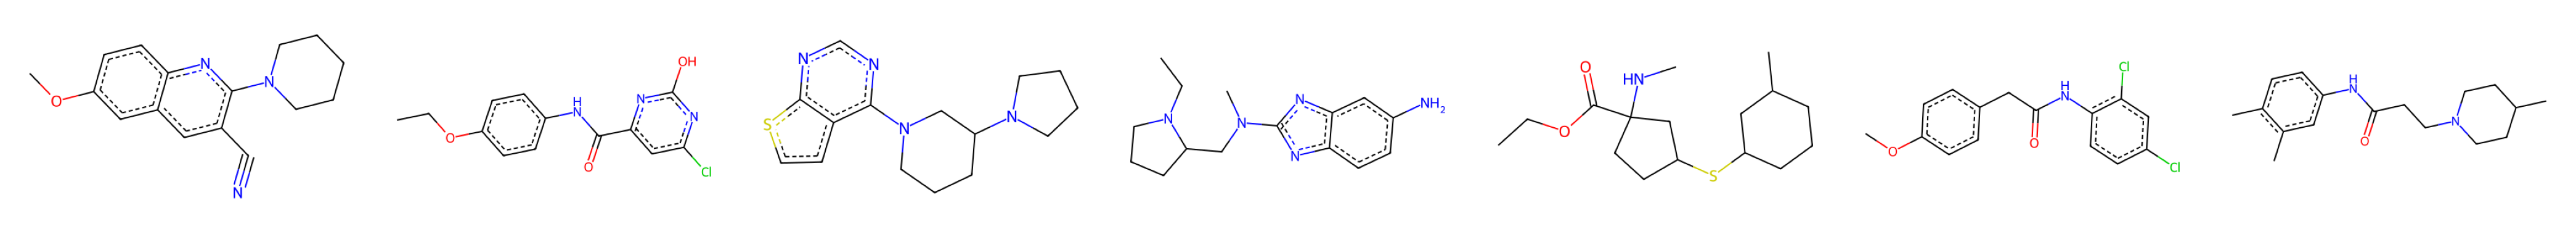

Generated molecules:


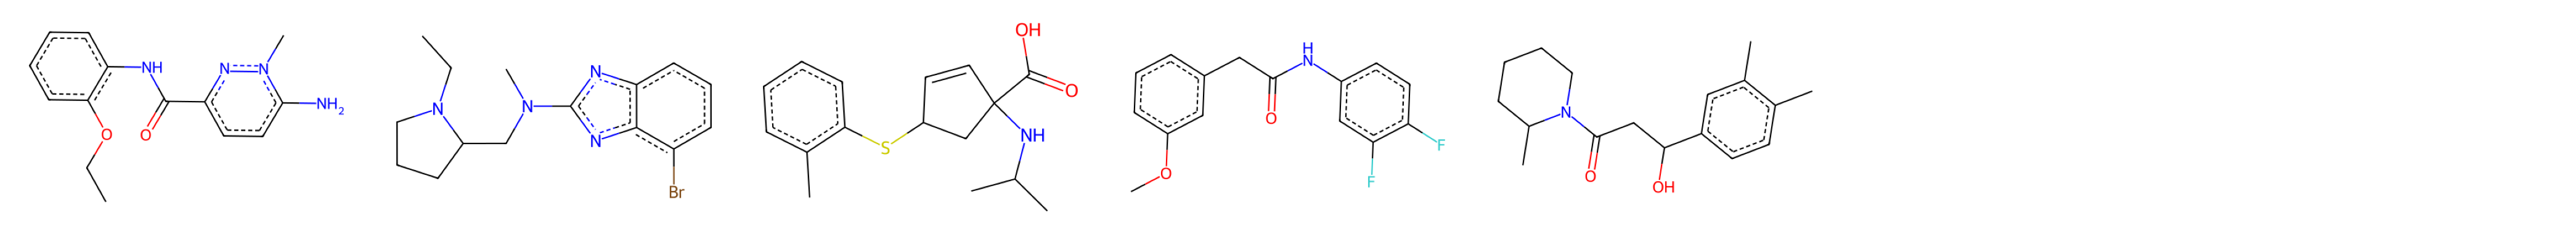

In [47]:
source_graphs = [generator.stored_graphs_[i] for i in generator.last_sampled_indices_]

print("Source molecules:")
_ = display_graphs(source_graphs, n_graphs_per_line=max(1, len(source_graphs)))

print("Generated molecules:")
_ = display_graphs(samples, n_graphs_per_line=max(1, n_samples * n_instances_per_sample))


---